In [1]:
import networkx as nx
import numpy as np

from qiskit.visualization import array_to_latex

L = 0.5 * np.array(
    [
        [1, 0, -1, 0],
        [0, 0, 0, 0],
        [-1, 0, 1, 0],
        [0, 0, 0, 0],
    ]
)

array_to_latex(L, prefix=r"\mathbf{L}_{\mathrm{p-local}} = ")

<IPython.core.display.Latex object>

In [2]:
from qiskit.quantum_info import SparsePauliOp

SparsePauliOp.from_operator(L)

SparsePauliOp(['II', 'IZ', 'XI', 'XZ'],
              coeffs=[ 0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j])

In [3]:
graph_style = dict(
    with_labels=True, 
    node_size=600,         # Much larger nodes so the numbers fit inside
    node_color="lightblue",# Lighter color for better text contrast
    edgecolors="black",    # Add a border to the nodes
    linewidths=1.5,        # Thickness of the node borders
    font_size=12,          # Larger, readable text
    font_weight="bold",
    edge_color="gray"      # Make edges slightly subtle if they exist
)

DPI = 300
MARGINS = 0.05
FIGSIZE = (4, 4)

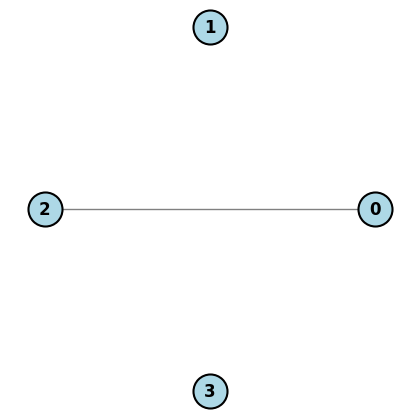

In [4]:
import matplotlib.pyplot as plt
from qsga.util import transform_laplacian_to_graph

G = transform_laplacian_to_graph(L)
plt.figure(figsize=FIGSIZE)

# 3. Calculate a layout with increased spacing (k) to push nodes apart
# Using a seed ensures the layout looks the same every time you run it
pos = nx.circular_layout(G)

# 4. Draw the graph with enhanced parameters
nx.draw(
    G, 
    pos=pos,               # Use the layout calculated above
    **graph_style
)

# 5. Add a margin so outer nodes don't get cut off by the figure edges
plt.margins(MARGINS)
plt.savefig("local_pertubation.png", dpi=DPI)
plt.show()

In [5]:
from qsga.hamiltonian_generators import scale_m_local_perturbation, PerturbationScalingMethod

m_local_dim = 2
q_global_dim=4

pseudo_rng = np.random.default_rng(seed=32)

L_scaled_sparse = scale_m_local_perturbation(
    m_local_perturbation=L,
    q_global_dim=q_global_dim,
    scaling_method=PerturbationScalingMethod.SCRAMBLE,
    pseudo_rng=pseudo_rng
)

L_scaled_sparse

SparsePauliOp(['IIII', 'IIIZ', 'IXII', 'IXIZ'],
              coeffs=[ 0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j])

In [6]:
array_to_latex(L_scaled_sparse, max_size=16)

<IPython.core.display.Latex object>

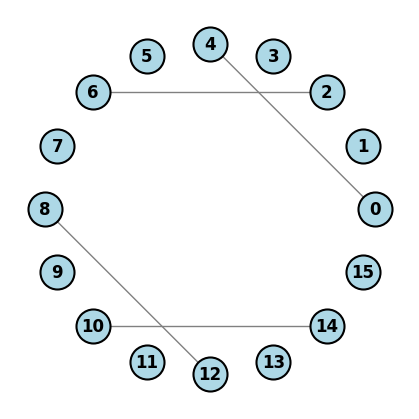

In [7]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. Assign the graph to a variable first
G = transform_laplacian_to_graph(L_scaled_sparse)

# 2. Increase the figure size significantly
plt.figure(figsize=FIGSIZE)

# 3. Calculate a layout with increased spacing (k) to push nodes apart
# Using a seed ensures the layout looks the same every time you run it
global_pos = nx.circular_layout(G)

# 4. Draw the graph with enhanced parameters
nx.draw(
    G, 
    pos=global_pos,               # Use the layout calculated above
    **graph_style
)

# 5. Add a margin so outer nodes don't get cut off by the figure edges
plt.margins(MARGINS)
plt.savefig("scaled_perturbarion.png", dpi=DPI)
plt.show()

SparsePauliOp(['II', 'IZ', 'XI', 'XZ'],
              coeffs=[ 1.098555+0.j,  1.098555+0.j, -1.098555+0.j, -1.098555+0.j])
SparsePauliOp(['IIII', 'IIIZ', 'IXII', 'IXIZ', 'IIZI', 'IXZI'],
              coeffs=[ 1.348555+0.j,  0.25    +0.j, -1.348555+0.j, -0.25    +0.j,  1.098555+0.j,
 -1.098555+0.j])


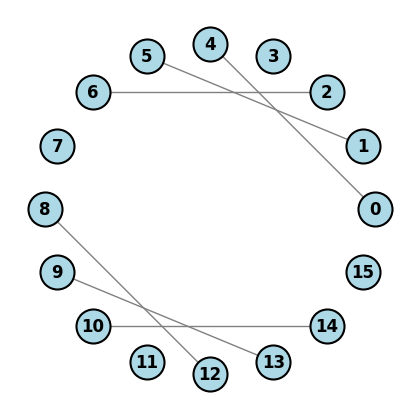


SparsePauliOp(['II', 'IZ', 'XI', 'XZ'],
              coeffs=[ 2.42536805+0.j, -2.42536805+0.j, -2.42536805+0.j,  2.42536805+0.j])
SparsePauliOp(['IIII', 'IIIZ', 'IXII', 'IXIZ', 'IIZI', 'IXZI', 'IZII', 'XIII', 'XZII'],
              coeffs=[ 3.77392305+0.j,  0.25      +0.j, -1.348555  +0.j, -0.25      +0.j,
  1.098555  +0.j, -1.098555  +0.j, -2.42536805+0.j, -2.42536805+0.j,
  2.42536805+0.j])


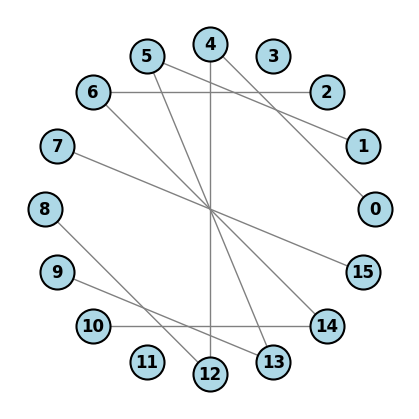

In [8]:
from qsga.hamiltonian_generators import obtain_random_m_local_perturbation
from copy import deepcopy

num_additional_perturbations = 2
local_perturbations = []
combined_scaled_perturbation = deepcopy(L_scaled_sparse)

pseudo_rng = np.random.default_rng(seed=32)
weights_range = (0.5, 5)

for index in range(num_additional_perturbations):
    local_perturbation = obtain_random_m_local_perturbation(
        m_local_dim,
        weights_range=weights_range,
        pseudo_rng=pseudo_rng
    )
    local_perturbations.append(local_perturbation)
    print(local_perturbation)
    
    combined_scaled_perturbation += scale_m_local_perturbation(
        m_local_perturbation=local_perturbation,
        q_global_dim=q_global_dim,
        scaling_method=PerturbationScalingMethod.SCRAMBLE,
        pseudo_rng=pseudo_rng
    )
    combined_scaled_perturbation = combined_scaled_perturbation.simplify()
    print(combined_scaled_perturbation)
    
    # 1. Assign the graph to a variable first
    G = transform_laplacian_to_graph(combined_scaled_perturbation)

    # 2. Increase the figure size significantly
    plt.figure(figsize=FIGSIZE)

    # 4. Draw the graph with enhanced parameters
    nx.draw(
        G, 
        pos=global_pos,               # Use the layout calculated above
        **graph_style
    )

    # 5. Add a margin so outer nodes don't get cut off by the figure edges
    plt.margins(MARGINS)
    
    if index == num_additional_perturbations - 1:
        plt.savefig("three_scaled_perturbations.png", dpi=DPI)
        
    plt.show()
    print()


In [9]:
array_to_latex(combined_scaled_perturbation, max_size=16, precision=2)

<IPython.core.display.Latex object>

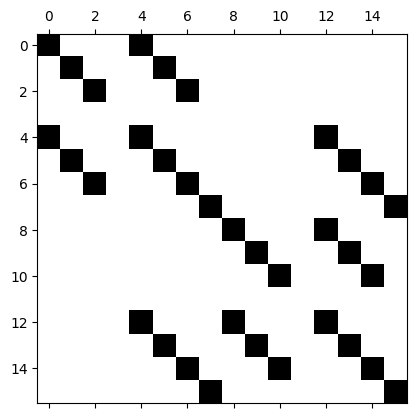

In [10]:
plt.spy(combined_scaled_perturbation)

2026-05-26 14:17:25 [INFO] [obtain_skeleton_laplacian] execution time: 0.000367 seconds
SparsePauliOp(['IIII', 'XIXI', 'IXIX'],
              coeffs=[ 2.+0.j, -1.+0.j, -1.+0.j])


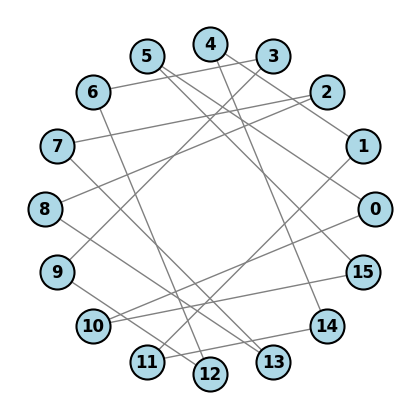

In [11]:
from qsga.hamiltonian_generators import obtain_skeleton_laplacian
from qsga.util import transform_laplacian_to_graph

pseudo_rng = np.random.default_rng(seed=32)

skeleton_laplacian = obtain_skeleton_laplacian(n=q_global_dim, d=2, max_locality=2, pseudo_rng=pseudo_rng)
print(skeleton_laplacian)

skeleton_graph = transform_laplacian_to_graph(skeleton_laplacian)

plt.figure(figsize=FIGSIZE)
nx.draw(skeleton_graph, pos=global_pos, **graph_style)

plt.savefig("skeleton_graph.png", dpi=DPI)

SparsePauliOp(['IIII', 'XIXI', 'IXIX', 'IIII', 'IIIZ', 'IXII', 'IXIZ', 'IIZI', 'IXZI', 'IZII', 'XIII', 'XZII'],
              coeffs=[ 2.        +0.j, -1.        +0.j, -1.        +0.j,  3.77392305+0.j,
  0.25      +0.j, -1.348555  +0.j, -0.25      +0.j,  1.098555  +0.j,
 -1.098555  +0.j, -2.42536805+0.j, -2.42536805+0.j,  2.42536805+0.j])


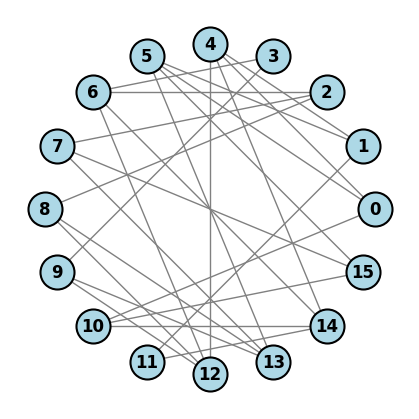

In [12]:
rop_laplacian = skeleton_laplacian + combined_scaled_perturbation
print(rop_laplacian)

rop_graph = transform_laplacian_to_graph(rop_laplacian)

plt.figure(figsize=FIGSIZE)
nx.draw(rop_graph, pos=global_pos, **graph_style)

plt.savefig("rop_graph.png", dpi=DPI)
plt.show()